In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import networkx as nx
from networkx.algorithms.components import node_connected_component
import community as community_louvain
from collections import defaultdict
from collections import Counter

In [215]:
use_cols_entities = [
    "node_id",          # ID unique (str)
    "name",             # Nom de l'entreprise
    "jurisdiction",     # Code du pays (ex: "PA" pour Panama)
    "jurisdiction_description",  # Nom complet (ex: "Panama")
    "company_type",     # Type d'entité (ex: "Offshore Company")
    "incorporation_date",  # Date de création (à convertir en datetime)
    "status",           # Statut (ex: "Active", "Inactive")
    "country_codes",    # Codes pays (ex: "PA", "KY" pour Cayman Islands)
    "countries",        # Noms de pays (ex: "Panama")
    "service_provider", # Prestataire (ex: "Mossack Fonseca" → indicateur fort)
    "sourceID"          # Source (ex: "Panama Papers")
]

use_cols_addresses = [
    "node_id",          # ID de l'adresse
    "name",             # Adresse complète
    "country_codes",    # Codes pays (ex: "KY" pour Cayman Islands)
    "countries"         # Noms de pays
]

use_cols_officers = [
    "node_id",          # ID du dirigeant
    "name",             # Nom complet
    "country_codes",    # Pays de résidence
    "countries"
]

use_cols_intermediaries = [
    "node_id",
    "name",
    "country_codes",
    "countries"
]

use_cols_relationships = [
    "node_id_start",    # ID du nœud source (str)
    "node_id_end",      # ID du nœud cible (str)
    "rel_type",         # Type de relation (ex: "registered_address", "officer")
    "start_date",       # Date de début (à convertir en datetime)
    "end_date",         # Date de fin
    "status",           # Statut (ex: "Active")
    "sourceID"          # Source (ex: "Panama Papers")
]

In [216]:
nodes_entities = pd.read_csv(
    "nodes-entities.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_entities,
    parse_dates=["incorporation_date"],  # Conversion automatique en datetime
    dayfirst=True  # Pour les dates au format "JJ-MMM-AAAA"
)

nodes_addresses = pd.read_csv(
    "nodes-addresses.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_addresses
)

nodes_officers = pd.read_csv(
    "nodes-officers.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_officers
)

nodes_intermediaries = pd.read_csv(
    "nodes-intermediaries.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_intermediaries
)

relationships = pd.read_csv(
    "relationships.csv",
    dtype={"node_id_start": "str", "node_id_end": "str"},
    usecols=use_cols_relationships,
    parse_dates=["start_date", "end_date"],
    dayfirst=True
)


/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_6397/234046201.py:1: DtypeWarning: Columns (6,13,14,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  nodes_entities = pd.read_csv(
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_6397/234046201.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nodes_entities = pd.read_csv(
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_6397/234046201.py:27: DtypeWarning: Columns (4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  relationships = pd.read_csv(
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_6397/234046201.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
 

In [217]:

# Initialiser un graphe orienté
G = nx.DiGraph()

# --- AJOUTER LES NŒUDS ---

# 1. Nœuds "entités" (nodes-entities.csv)
for _, row in nodes_entities.iterrows():
    G.add_node(
        row["node_id"],
        type="entity",
        name=row["name"],
        jurisdiction=row["jurisdiction"],
        jurisdiction_description=row["jurisdiction_description"],
        country_codes=row["country_codes"],
        company_type=row["company_type"],
        status=row["status"],
        sourceID=row["sourceID"] if "sourceID" in row else None
    )

# 2. Nœuds "adresses" (nodes-addresses.csv)
for _, row in nodes_addresses.iterrows():
    G.add_node(
        row["node_id"],
        type="address",
        name=row["name"],
        country_codes=row.get("country_codes"),
        countries=row.get("countries")
    )

# 3. Nœuds "dirigeants" (nodes-officers.csv)
for _, row in nodes_officers.iterrows():
    G.add_node(
        row["node_id"],
        type="officer",
        name=row["name"],
        country_codes=row.get("country_codes"),
        countries=row.get("countries")
    )

# 4. Nœuds "intermédiaires" (nodes-intermediaries.csv)
for _, row in nodes_intermediaries.iterrows():
    G.add_node(
        row["node_id"],
        type="intermediary",
        name=row["name"],
        country_codes=row.get("country_codes"),
        countries=row.get("countries")
    )


# --- AJOUTER LES RELATIONS --- (relationships.csv)
for _, row in relationships.iterrows():
    G.add_edge(
        row["node_id_start"],
        row["node_id_end"],
        rel_type=row["rel_type"],
        status=row.get("status"),
        sourceID=row.get("sourceID")
    )

print(f"Graphe construit avec {G.number_of_nodes()} nœuds et {G.number_of_edges()} relations.")


Graphe construit avec 2016523 nœuds et 2897134 relations.


In [218]:
low_degree_nodes = [node for node in G.nodes() if G.degree(node) == 0]
G.remove_nodes_from(low_degree_nodes)

print(f"Graphe après suppression des nœuds de faible degré : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes.")

Graphe après suppression des nœuds de faible degré : 2016165 nœuds, 2897134 arêtes.


In [289]:
# Liste des codes/juridictions pour les États-Unis
us_criteria = [
    "US", "US-DE", "Delaware", "United States", "USA"
]

# Fonction pour vérifier si un nœud est américain
def is_us_node(node_id):
    node = G.nodes[node_id]
    jurisdiction = node.get("jurisdiction", "")
    country_codes = node.get("country_codes", "")
    jurisdiction_desc = node.get("jurisdiction_description", "")

    return (
        jurisdiction in us_criteria or
        any(code in us_criteria for code in str(country_codes).split(",")) or
        any(crit in str(jurisdiction_desc) for crit in us_criteria)
    )

# Extraire les nœuds américains
us_nodes = [node for node in G.nodes() if is_us_node(node)]
print(f"Nombre d'entités américaines : {len(us_nodes)}")

Nombre d'entités américaines : 56512


In [290]:
# --- Étape 1 : Trouver tous les nœuds accessibles depuis les entreprises américaines ---
us_nodes = [node for node in G.nodes() if is_us_node(node)]  # (utilisez la fonction is_us_node() définie précédemment)

# Ensemble des nœuds à conserver (initialement : les nœuds US + leurs voisins)
nodes_to_keep = set(us_nodes)

# Parcourir tous les nœuds US et ajouter leurs voisins (même indirects)
for us_node in us_nodes:
    # Utiliser BFS (Breadth-First Search) pour explorer tous les nœuds connectés
    for node in nx.descendants(G, us_node):  # Tous les nœuds accessibles depuis us_node
        nodes_to_keep.add(node)
    for node in nx.ancestors(G, us_node):    # Tous les nœuds qui mènent à us_node
        nodes_to_keep.add(node)


subgraph = G.subgraph(nodes_to_keep).copy()

print(f"Sous-graphe final : {subgraph.number_of_nodes()} nœuds, {subgraph.number_of_edges()} arêtes.")


Sous-graphe final : 92810 nœuds, 161486 arêtes.


In [291]:
paradis_fiscaux = {
    # ⭐⭐⭐ Paradis fiscaux notoires (liste noire UE/OCDE + ICIJ)
    "AIA": "Anguilla",
    "BMU": "Bermudes",
    "VGB": "Îles Vierges britanniques",
    "CYM": "Îles Caïmans",
    "GIB": "Gibraltar",
    "JEY": "Jersey",
    "GGY": "Guernesey",  # Ajouté car souvent utilisé comme paradis fiscal (bien que sous Royaume-Uni)
    "MCO": "Monaco",
    "PAN": "Panama",
    "SGP": "Singapour",
    "CHE": "Suisse",
    "HKG": "Hong Kong",
    "MAC": "Macao",
    "KNA": "Saint-Christophe-et-Niévès",
    "LCA": "Sainte-Lucie",
    "VCT": "Saint-Vincent-et-les-Grenadines",
    "WSM": "Samoa",
    "BHR": "Bahrein",
    "ARE": "Émirats arabes unis",
    "QAT": "Qatar",
    "BHS": "Bahamas",
    "BRB": "Barbade",
    "BLZ": "Belize",
    "CUR": "Curaçao",  # Pays-Bas caribéens
    "ABW": "Aruba",
    "SXM": "Saint-Martin (partie néerlandaise)",
    "BES": "Bonaire, Saint-Eustache et Saba",
    "VUT": "Vanuatu",
    "TON": "Tonga",
    "MHL": "Îles Marshall",
    "FSM": "États fédérés de Micronésie",  # Si présent dans votre graphe
    "PLW": "Palaos",
    "SLB": "Îles Salomon",
    "FLK": "Îles Malouines",  # Rarement utilisé mais parfois cité
    "COK": "Îles Cook",  # Paradis fiscal du Pacifique
    "NIU": "Niue",
    "NFK": "Île Norfolk",

    # ⭐⭐ Paradis fiscaux "passe-plats" (optimisation fiscale légale)
    "NLD": "Pays-Bas",  # Sandwich néerlandais
    "IRL": "Irlande",  # Double Irish
    "LUX": "Luxembourg",
    "CYP": "Chypre",
    "MLT": "Malte",
    "AND": "Andorre",
    "LIE": "Liechtenstein",
    "SMR": "Saint-Marin",



    # 🇺🇸 États/juridictions offshore aux USA (à ajouter si pertinent)
    "USA-DE": "Delaware",  # Code non-standard, mais souvent utilisé comme paradis fiscal interne
    "USA-WY": "Wyoming",
    "USA-NV": "Nevada",

    # 🇬🇧 Juridictions offshore britanniques
    "VGB": "Îles Vierges britanniques",  # Déjà présent
    "CYM": "Îles Caïmans",  # Déjà présent
    "MSR": "Montserrat",
    "SHN": "Sainte-Hélène",  # Rarement utilisé
    "PCN": "Îles Pitcairn",

}

# Liste des codes ISO pour une recherche rapide
paradis_fiscaux_codes = set(paradis_fiscaux.keys())

# Liste des noms complets (pour correspondre aux noms dans votre graphe)
paradis_fiscaux_noms = set(paradis_fiscaux.values())

# Ajout des noms alternatifs (ex : "Curaçao" vs "Curacao")
paradis_fiscaux_noms.update([
    "Curacao", "Curaçao",  # Variantes orthographiques
    "Bolivarian Republic of Venezuela",  # Nom officiel
    "Venezuelan Bolivarian Republic",
    "Brunei Darussalam",  # Variantes
    "Côte d'Ivoire",  # Présent dans votre graphe
    "Democratic Republic of the Congo",  # Pour "COD"
    "Republic of Korea",  # "KOR"
    "United States Minor Outlying Islands",  # Paradis fiscal méconnu
    "British Virgin Islands",  # Équivalent de "VGB"
    "U.S. Virgin Islands",  # Équivalent de "VIR" (si présent)
    "Taiwan", "Province of China Taiwan",  # Cas particulier
    "State of Palestine",
    "Russian Federation",
    "Bahamas"  # Équivalent de "RUS"
    "Vatican City",  # Si présent (non listé ici mais parfois utilisé)
])


In [292]:
#Ajout du label "is_tax_haven" aux nœuds


for node in subgraph.nodes():
    is_tax_haven = "No"  # Valeur par défaut

    if "country_codes" in subgraph.nodes[node]:
        countries = subgraph.nodes[node]["country_codes"]

        # Gérer les cas spéciaux : None, float, int, etc.
        if countries is None:
            continue  # On ignore les valeurs manquantes
        elif isinstance(countries, (float, int)):
            continue  # On ignore les nombres
        elif isinstance(countries, str):
            # Si c'est une chaîne, on vérifie directement
            if countries in paradis_fiscaux_codes:
                is_tax_haven = "Yes"
        elif isinstance(countries, (list, tuple, set)):
            # Si c'est une liste, on parcourt chaque élément
            for country in countries:
                if isinstance(country, str) and country in paradis_fiscaux_codes:
                    is_tax_haven = "Yes"
                    break  # Pas besoin de vérifier les autres pays
        else:
            # Cas inattendu (ex: dict, bool, etc.)
            continue

    # Ajouter le label au nœud
    subgraph.nodes[node]["is_tax_haven"] = is_tax_haven

In [299]:
import random
# add approximation of betweenness centrality  attribute to each node
k = int(0.1 * subgraph.number_of_nodes())
nodes = random.sample(list(subgraph.nodes()), k)

# Calcul approximatif de la betweenness (méthode officielle de NetworkX)
betweenness = nx.betweenness_centrality(subgraph, k=k, normalized=True)



KeyboardInterrupt: 

In [ ]:
for node in subgraph.nodes():
    is_bi_national = "No"  
    if "country_codes" in subgraph.nodes[node]:
        countries = subgraph.nodes[node]["country_codes"]
        if countries is None:
            continue
        elif isinstance(countries, (float, int)):
            continue  # On ignore les nombres
        elif isinstance(countries, str):
            # Si c'est une chaîne, on vérifie directement
            if ";" in countries:
                is_tax_haven = "Yes"
        elif isinstance(countries, (list, tuple, set)):
            # Si c'est une liste, on parcourt chaque élément
            for country in countries:
                if isinstance(country, str) and ";" in country:
                    is_bi_national = "Yes"
                    break  # Pas besoin de vérifier les autres pays
        else:
            # Cas inattendu (ex: dict, bool, etc.)
            continue
    subgraph.nodes[node]["is_bi_national"] = is_bi_national

In [167]:
# Sauvegarder le sous-graphe dans un fichier GEXF
nx.write_gexf(subgraph, "us_tax_havens_network_2.gexf")

Début de l'étude 

In [168]:
def resume_graphe(G, type_node_attr='type', type_edge_attr='relation'):
    """
    Affiche un résumé complet d'un graphe NetworkX.
    
    Args:
        G (nx.Graph ou nx.DiGraph): Le graphe à analyser.
        type_node_attr (str): Le nom de l'attribut qui définit le type de noeud (ex: 'entity_type', 'label').
                               Si inconnu, le script essaiera de deviner ou affichera les clés disponibles.
        type_edge_attr (str): Le nom de l'attribut qui définit le type de relation (ex: 'role', 'type').
    """
    print("-" * 30)
    print("📊 RÉSUMÉ DU GRAPHE")
    print("-" * 30)

    # 1. Volumétrie de base
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    print(f"🔹 Nombre total de noeuds : {n_nodes}")
    print(f"🔹 Nombre total d'arêtes : {n_edges}")
    
    # Densité
    density = nx.density(G)
    print(f"🔹 Densité du graphe     : {density:.6f}")
    
    # Composantes connexes (si le graphe n'est pas dirigé ou faiblement connexe pour dirigé)
    if G.is_directed():
        n_components = nx.number_weakly_connected_components(G)
        print(f"🔹 Composantes connexes (faibles) : {n_components}")
    else:
        n_components = nx.number_connected_components(G)
        print(f"🔹 Composantes connexes : {n_components}")

    print("\n" + "-" * 30)
    print("🏷️  ATTRIBUTS ET LABELS")
    print("-" * 30)

    if n_nodes > 0:
        # Récupérer un noeud exemple pour voir les clés
        sample_node = list(G.nodes(data=True))[0]
        print(f"📋 Exemples d'attributs sur un noeud : {list(sample_node[1].keys())}")
        
        # Analyser la distribution des types de noeuds
        # On vérifie si l'attribut spécifié existe, sinon on prend le premier attribut trouvé
        types_nodes = [d.get(type_node_attr, "Non défini") for n, d in G.nodes(data=True)]
        count_nodes = Counter(types_nodes)
        
        print(f"\n🔸 Répartition des types de noeuds (basé sur '{type_node_attr}') :")
        for type_n, count in count_nodes.most_common():
            print(f"   - {type_n}: {count}")

    if n_edges > 0:
        # Récupérer une arête exemple
        sample_edge = list(G.edges(data=True))[0]
        print(f"\n📋 Exemples d'attributs sur une arête : {list(sample_edge[2].keys())}")

        # Analyser la distribution des types d'arêtes
        types_edges = [d.get(type_edge_attr, "Non défini") for u, v, d in G.edges(data=True)]
        count_edges = Counter(types_edges)
        
        print(f"\n🔸 Répartition des types d'arêtes (basé sur '{type_edge_attr}') :")
        for type_e, count in count_edges.most_common():
            print(f"   - {type_e}: {count}")

    print("-" * 30)

resume_graphe(subgraph, type_node_attr='type', type_edge_attr='rel_type')

------------------------------
📊 RÉSUMÉ DU GRAPHE
------------------------------
🔹 Nombre total de noeuds : 92810
🔹 Nombre total d'arêtes : 161486
🔹 Densité du graphe     : 0.000019
🔹 Composantes connexes (faibles) : 3664

------------------------------
🏷️  ATTRIBUTS ET LABELS
------------------------------
📋 Exemples d'attributs sur un noeud : ['type', 'name', 'country_codes', 'countries', 'is_tax_haven']

🔸 Répartition des types de noeuds (basé sur 'type') :
   - officer: 42349
   - address: 27596
   - entity: 20933
   - intermediary: 1686
   - Non défini: 246

📋 Exemples d'attributs sur une arête : ['rel_type', 'status', 'sourceID']

🔸 Répartition des types d'arêtes (basé sur 'rel_type') :
   - officer_of: 87575
   - registered_address: 58689
   - intermediary_of: 9954
   - similar: 2200
   - same_name_as: 1198
   - connected_to: 1172
   - same_company_as: 401
   - same_as: 177
   - underlying: 80
   - same_id_as: 22
   - probably_same_officer_as: 11
   - similar_company_as: 7
-----

Nombre de composantes connexes dans le sous-graphe : 3664
Taille de la plus grande composante connexe : 48252


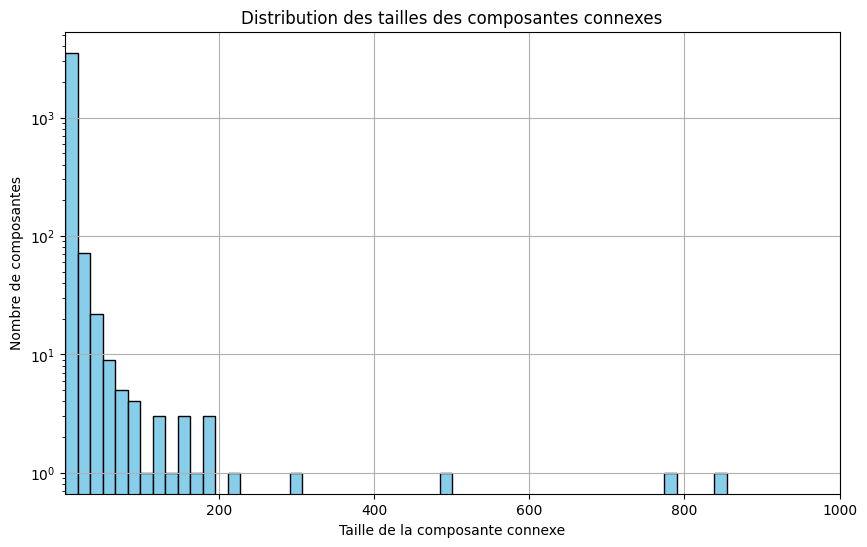

In [101]:
# Composantes connexes 


print("Nombre de composantes connexes dans le sous-graphe :", nx.number_connected_components(subgraph.to_undirected()))

#PLus grande composante connexe
largest_cc = max(nx.connected_components(subgraph.to_undirected()), key=len)
print("Taille de la plus grande composante connexe :", len(largest_cc))
G_largest_cc = subgraph.subgraph(largest_cc).copy()


# Taille des communautés détectées

Connnected_components = list(nx.connected_components(subgraph.to_undirected()))
community_sizes = [len(c) for c in Connnected_components]

plt.figure(figsize=(10, 6))
plt.hist(community_sizes, bins=3000, color='skyblue', edgecolor='black')
plt.title('Distribution des tailles des composantes connexes')
plt.xlabel('Taille de la composante connexe')
plt.ylabel('Nombre de composantes')
plt.xlim(1, 1000)
plt.yscale('log')  # Échelle logarithmique pour mieux visualiser
plt.grid(True)
plt.show()


In [140]:

nx.write_gexf(G_largest_cc, "us_tax_havens_network_largest_cc.gexf")

In [11]:
# Détection des communautés avec l'algorithme de Louvain

partition = community_louvain.best_partition(subgraph.to_undirected())

print(f"Nombre de communautés détectées : {len(set(partition.values()))}")


Nombre de communautés détectées : 4497


In [12]:
print("partition est de type :", type(partition))

partition est de type : <class 'dict'>


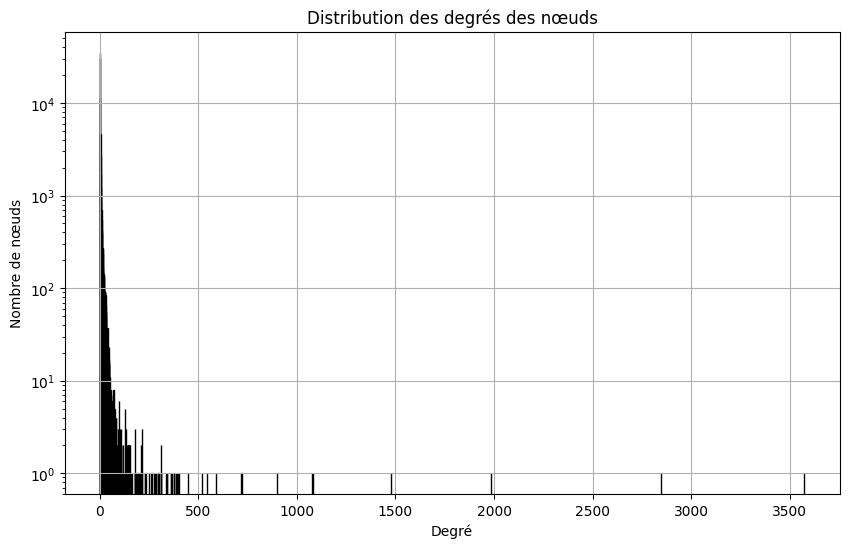

In [30]:
# Degrés des noueds
degrees = dict(subgraph.degree())
degree_values = list(degrees.values())
plt.figure(figsize=(10, 6))
plt.hist(degree_values, bins=range(1, max(degree_values) + 1), color='lightgreen', edgecolor='black')
plt.title('Distribution des degrés des nœuds')
plt.xlabel('Degré')
plt.ylabel('Nombre de nœuds')
#plt.xlim(1, 100)
plt.yscale('log')  # Échelle logarithmique pour mieux visualiser
plt.grid(True)
plt.show()

In [169]:
# Réinitialiser stats avec les nouveaux champs
stats = defaultdict(lambda: {
    "in_degree": [],
    "out_degree": [],
    "net_degree": [],
    "in_edges_by_type": defaultdict(int),  # Compteur d'arêtes entrantes par rel_type
    "out_edges_by_type": defaultdict(int), # Compteur d'arêtes sortantes par rel_type
})

# Parcourir tous les nœuds
for node in subgraph.nodes():
    node_type = subgraph.nodes[node].get("type", "unknown")

    # --- Degrés classiques ---
    in_deg = subgraph.in_degree(node)
    out_deg = subgraph.out_degree(node)
    net_deg = in_deg - out_deg

    stats[node_type]["in_degree"].append(in_deg)
    stats[node_type]["out_degree"].append(out_deg)
    stats[node_type]["net_degree"].append(net_deg)

    # --- Analyse des rel_type pour les arêtes entrantes ---
    for predecessor, _, edge_data in subgraph.in_edges(node, data=True):
        rel_type = edge_data.get("rel_type", "unknown")
        stats[node_type]["in_edges_by_type"][rel_type] += 1

    # --- Analyse des rel_type pour les arêtes sortantes ---
    for _, successor, edge_data in subgraph.out_edges(node, data=True):
        rel_type = edge_data.get("rel_type", "unknown")
        stats[node_type]["out_edges_by_type"][rel_type] += 1

# Calculer les proportions (après la boucle)
for node_type in stats:
    total_in = sum(stats[node_type]["in_edges_by_type"].values()) or 1  # Éviter division par 0
    total_out = sum(stats[node_type]["out_edges_by_type"].values()) or 1

    # Convertir les comptes en proportions
    stats[node_type]["in_edges_proportions"] = {
        rel_type: count 
        for rel_type, count in stats[node_type]["in_edges_by_type"].items()
    }
    stats[node_type]["out_edges_proportions"] = {
        rel_type: count 
        for rel_type, count in stats[node_type]["out_edges_by_type"].items()
    }

# Calculer et afficher les moyennes
print("=== Degrés moyens par type de nœud ===")
for node_type, data in stats.items():
    avg_in = sum(data["in_degree"]) / len(data["in_degree"]) if data["in_degree"] else 0
    avg_out = sum(data["out_degree"]) / len(data["out_degree"]) if data["out_degree"] else 0
    avg_net = sum(data["net_degree"]) / len(data["net_degree"]) if data["net_degree"] else 0

    print(f"\nType: {node_type}")
    print(f"  Degré entrant moyen: {avg_in:.2f}")
    print(f"  Degré sortant moyen: {avg_out:.2f}")
    print(f"  Degré net moyen: {avg_net:.2f}")
    print(f"  Nombre de nœuds: {len(data['in_degree'])}")


print("=== Proportions des types de relations par type de nœud ===")
for node_type, data in stats.items():
    print(f"\nType: {node_type}")

    print("  Proportions des types de relations entrantes :")
    for rel_type, proportion in data["in_edges_proportions"].items():
        print(f"    {rel_type}: {proportion:.4f}")

    print("  Proportions des types de relations sortantes :")
    for rel_type, proportion in data["out_edges_proportions"].items():
        print(f"    {rel_type}: {proportion:.4f}")


=== Degrés moyens par type de nœud ===

Type: officer
  Degré entrant moyen: 0.08
  Degré sortant moyen: 3.02
  Degré net moyen: -2.94
  Nombre de nœuds: 42349

Type: address
  Degré entrant moyen: 2.12
  Degré sortant moyen: 0.00
  Degré net moyen: 2.12
  Nombre de nœuds: 27596

Type: entity
  Degré entrant moyen: 4.75
  Degré sortant moyen: 0.95
  Degré net moyen: 3.81
  Nombre de nœuds: 20933

Type: intermediary
  Degré entrant moyen: 0.00
  Degré sortant moyen: 7.48
  Degré net moyen: -7.47
  Nombre de nœuds: 1686

Type: unknown
  Degré entrant moyen: 0.02
  Degré sortant moyen: 4.86
  Degré net moyen: -4.84
  Nombre de nœuds: 246
=== Proportions des types de relations par type de nœud ===

Type: officer
  Proportions des types de relations entrantes :
    similar: 2192.0000
    same_name_as: 1145.0000
    probably_same_officer_as: 11.0000
    same_as: 1.0000
    same_id_as: 22.0000
    underlying: 10.0000
    officer_of: 1.0000
  Proportions des types de relations sortantes :
    

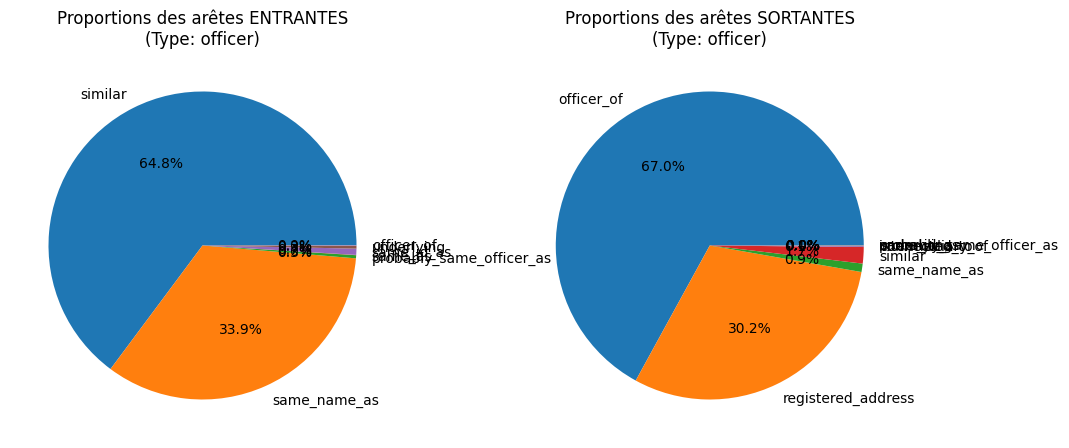

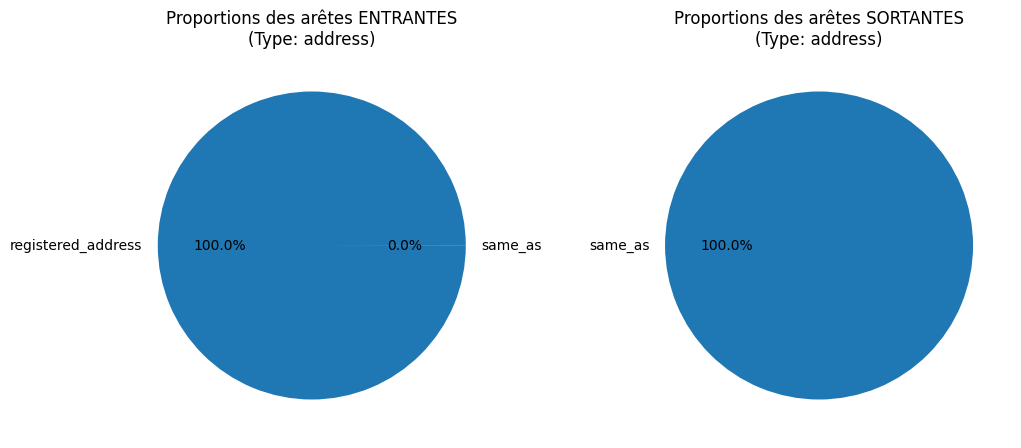

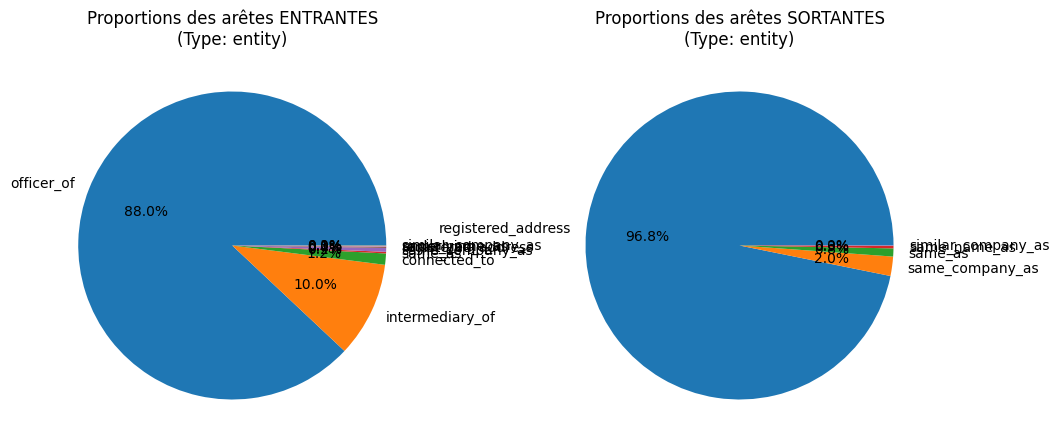

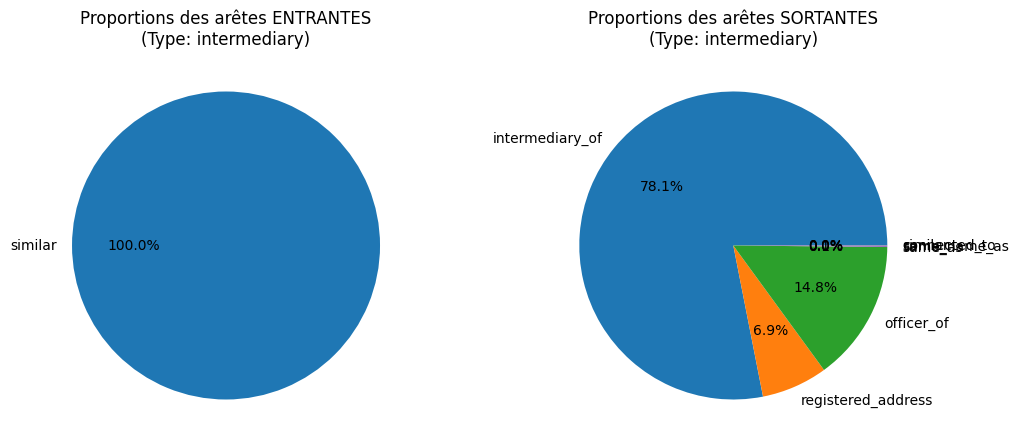

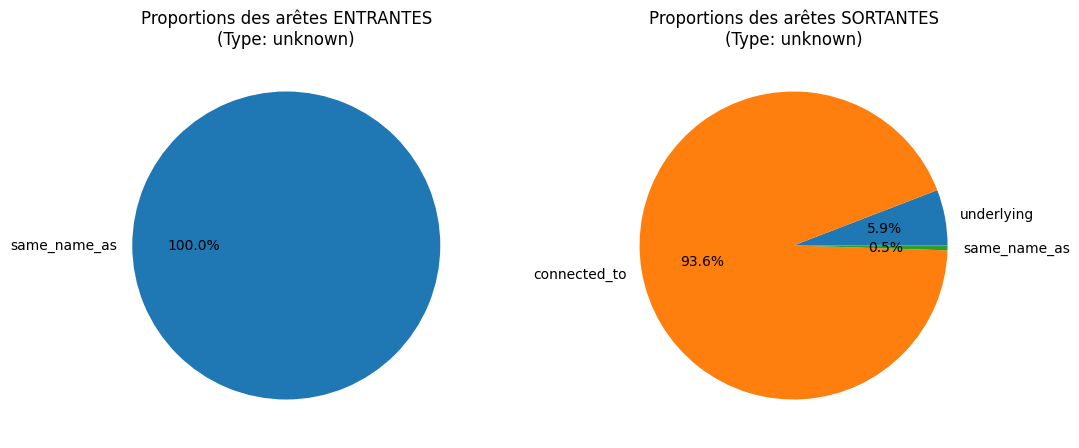

In [110]:
for node_type in stats:
    # Arêtes entrantes
    labels_in = list(stats[node_type]["in_edges_proportions"].keys())
    sizes_in = list(stats[node_type]["in_edges_proportions"].values())

    # Arêtes sortantes
    labels_out = list(stats[node_type]["out_edges_proportions"].keys())
    sizes_out = list(stats[node_type]["out_edges_proportions"].values())

    # Créer les camemberts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.pie(sizes_in, labels=labels_in, autopct='%1.1f%%')
    ax1.set_title(f"Proportions des arêtes ENTRANTES\n(Type: {node_type})")

    ax2.pie(sizes_out, labels=labels_out, autopct='%1.1f%%')
    ax2.set_title(f"Proportions des arêtes SORTANTES\n(Type: {node_type})")

    plt.show()

In [170]:

# Initialiser les statistiques par groupe (tax_haven vs non_tax_haven)
degree_stats = {
    "tax_haven": defaultdict(list),   # {type_noeud: [dict_degrés]}
    "non_tax_haven": defaultdict(list) # Idem pour les non-paradis fiscaux
}

# Parcourir tous les nœuds du sous-graphe
for node in subgraph.nodes():
    # Récupérer les attributs du nœud
    node_data = subgraph.nodes[node]
    node_type = node_data.get("type", "unknown")
    is_tax_haven = node_data.get("is_tax_haven", "No") == "Yes"

    # Déterminer le groupe (tax_haven ou non)
    group = "tax_haven" if is_tax_haven else "non_tax_haven"

    # Calculer les degrés (correction : total_deg = in_deg + out_deg)
    in_deg = subgraph.in_degree(node)
    out_deg = subgraph.out_degree(node)
    total_deg = in_deg + out_deg  # Correction ici

    # Stocker les degrés dans le dictionnaire
    degree_stats[group][node_type].append({
        "in_degree": in_deg,
        "out_degree": out_deg,
        "total_degree": total_deg,
        "net_degree": in_deg - out_deg  # Optionnel : degré net (différence)
    })
# Calculer les moyennes et médianes par groupe et type
results = {}
for group in degree_stats:
    results[group] = {}
    for node_type, degrees in degree_stats[group].items():
        in_degrees = [d["in_degree"] for d in degrees]
        out_degrees = [d["out_degree"] for d in degrees]
        total_degrees = [d["net_degree"] for d in degrees]

        results[group][node_type] = {
            "count": len(degrees),
            "mean_in": np.mean(in_degrees) if in_degrees else 0,
            "median_in": np.median(in_degrees) if in_degrees else 0,
            "mean_out": np.mean(out_degrees) if out_degrees else 0,
            "median_out": np.median(out_degrees) if out_degrees else 0,
            "mean_total": np.mean(total_degrees) if total_degrees else 0,
            "median_total": np.median(total_degrees) if total_degrees else 0
        }

# Afficher les résultats
for group in results:
    print(f"\n=== Groupe: {group} ===")
    for node_type, stats in results[group].items():
        print(f"\nType: {node_type} (Nombre: {stats['count']})")
        print(f"  Degré entrant - Moyenne: {stats['mean_in']:.2f}, Médiane: {stats['median_in']:.2f}")
        print(f"  Degré sortant - Moyenne: {stats['mean_out']:.2f}, Médiane: {stats['median_out']:.2f}")
        print(f"  Degré total - Moyenne: {stats['mean_total']:.2f}, Médiane: {stats['median_total']:.2f}")


=== Groupe: tax_haven ===

Type: entity (Nombre: 9011)
  Degré entrant - Moyenne: 6.08, Médiane: 3.00
  Degré sortant - Moyenne: 1.10, Médiane: 1.00
  Degré total - Moyenne: 4.99, Médiane: 2.00

Type: address (Nombre: 891)
  Degré entrant - Moyenne: 14.98, Médiane: 1.00
  Degré sortant - Moyenne: 0.00, Médiane: 0.00
  Degré total - Moyenne: 14.98, Médiane: 1.00

Type: officer (Nombre: 1660)
  Degré entrant - Moyenne: 1.07, Médiane: 0.00
  Degré sortant - Moyenne: 6.02, Médiane: 2.00
  Degré total - Moyenne: -4.94, Médiane: -1.00

Type: intermediary (Nombre: 61)
  Degré entrant - Moyenne: 0.00, Médiane: 0.00
  Degré sortant - Moyenne: 52.82, Médiane: 2.00
  Degré total - Moyenne: -52.82, Médiane: -2.00

=== Groupe: non_tax_haven ===

Type: officer (Nombre: 40689)
  Degré entrant - Moyenne: 0.04, Médiane: 0.00
  Degré sortant - Moyenne: 2.90, Médiane: 2.00
  Degré total - Moyenne: -2.86, Médiane: -2.00

Type: address (Nombre: 26705)
  Degré entrant - Moyenne: 1.69, Médiane: 1.00
  Degré

In [171]:


# 1️⃣ Calculer les centralités pour TOUS les nœuds
def compute_centralities(graph):
    # Degree brut (non normalisé)
    degree = dict(graph.degree())

    # Betweenness non normalisé avec échantillonnage
    betweenness = nx.betweenness_centrality(
        graph,
        k=1000,  # Échantillonnage pour accélérer le calcul
        normalized=False  # Désactive la normalisation
    )

    # Closeness non normalisé
    closeness = nx.closeness_centrality(
        graph,
        wf_improved=True  # Algorithme amélioré pour les grands graphes
    )

    # Page rank non normalisé
    eigenvector = nx.pagerank(
        graph,
        max_iter=1000,
        tol=1e-6  # Tolérance pour la convergence
    )

    # Créer un DataFrame pour stocker les résultats
    centralities = pd.DataFrame(index=graph.nodes())
    centralities["degree"] = centralities.index.map(degree)
    centralities["betweenness"] = centralities.index.map(betweenness)
    centralities["closeness"] = centralities.index.map(closeness)
    centralities["eigenvector"] = centralities.index.map(eigenvector)

    # Ajouter les attributs du nœud (type, is_tax_haven)
    for node in graph.nodes():
        centralities.loc[node, "type"] = graph.nodes[node].get("type", "unknown")
        centralities.loc[node, "is_tax_haven"] = graph.nodes[node].get("is_tax_haven", "No") == "Yes"

    return centralities



In [172]:
centralities_df = compute_centralities(subgraph)


for _, row in centralities_df.iterrows():
    node = row.name
    if node in subgraph.nodes():
        subgraph.nodes[node]['degree'] = row['degree']
        subgraph.nodes[node]['betweenness'] = row['betweenness']
        subgraph.nodes[node]['closeness'] = row['closeness']
        subgraph.nodes[node]['eigenvector'] = row['eigenvector']





In [287]:
# _____________Tous les types de liens qui partent d'un noeud donné_____________


# L'ID cible
target_id = "54662" 

if target_id not in subgraph:
    print(f"❌ Le noeud {target_id} n'existe pas dans le graphe.")
else:
    print(f"🎯 ANALYSE CENTRALE DU NOEUD : {target_id}")
    # On récupère les infos du noeud lui-même pour contexte
    node_infos = subgraph.nodes[target_id]
    print(f"   Nom : {node_infos.get('name', 'N/A')}")
    print(f"   Type : {node_infos.get('type', 'N/A')}")
    print(f"   Pays : {node_infos.get('country_codes', 'N/A')}")
    print("-" * 50)

    # ---------------------------------------------------------
    # PARTIE 1 : LIENS SORTANTS (Ce que ce noeud contrôle/est)
    # ---------------------------------------------------------
    print("📤 LIENS SORTANTS (Target -> Vers les autres)")
    out_edges = subgraph.out_edges(target_id, data=True)
    
    out_types = [data.get('rel_type', 'Inconnu') for u, v, data in out_edges]
    out_countries = [subgraph.nodes[v].get('country_codes', 'N/A') for u, v, data in out_edges]
    
    if not out_types:
        print("   Aucun lien sortant.")
    else:
        for rel, count in Counter(out_types).most_common():
            print(f"   ➡ {rel} : {count}")
        print(f"   🌍 Pays ciblés : {dict(Counter(out_countries))}")

    print("-" * 50)

    # ---------------------------------------------------------
    # PARTIE 2 : LIENS ENTRANTS (Qui contrôle ce noeud)
    # ---------------------------------------------------------
    print("📥 LIENS ENTRANTS (Les autres -> Vers Target)")
    # On utilise in_edges ici
    in_edges = subgraph.in_edges(target_id, data=True)
    
    # Attention : dans in_edges(u, v), v est notre target_id, u est la source
    in_types = [data.get('rel_type', 'Inconnu') for u, v, data in in_edges]
    
    # On regarde le pays de 'u' (l'origine du lien)
    in_countries = [subgraph.nodes[u].get('country_codes', 'N/A') for u, v, data in in_edges]
    
    if not in_types:
        print("   Aucun lien entrant.")
    else:
        for rel, count in Counter(in_types).most_common():
            print(f"   ⬅ {rel} : {count}")
        print(f"   🌍 Pays d'origine : {dict(Counter(in_countries))}")

🎯 ANALYSE CENTRALE DU NOEUD : 54662
   Nom : Portcullis TrustNet (BVI) Limited
   Type : officer
   Pays : THA;VGB;IDN;SGP
--------------------------------------------------
📤 LIENS SORTANTS (Target -> Vers les autres)
   ➡ officer_of : 1075
   ➡ registered_address : 2
   🌍 Pays ciblés : {'VGB': 1046, 'VGB;CYM': 8, 'CYM;VGB': 10, 'VGB;GBR': 1, 'VGB;SGP': 3, 'VGB;USA': 5, 'USA;VGB': 1, 'HKG;VGB': 1, 'XXX;VGB': 2}
--------------------------------------------------
📥 LIENS ENTRANTS (Les autres -> Vers Target)
   ⬅ underlying : 1
   🌍 Pays d'origine : {'VGB;SGP;THA;FRA;MYS;TWN;HKG;IDN': 1}


In [213]:
cored_subgraph = nx.k_core(G, k=10)
print(f"Sous-graphe cored (k=3) : {cored_subgraph.number_of_nodes()} nœuds, {cored_subgraph.number_of_edges()} arêtes.")

cored_subgraph_cc = max(nx.connected_components(cored_subgraph.to_undirected()), key=len)
cored_subgraph = cored_subgraph.subgraph(cored_subgraph_cc).copy()
nx.write_gexf(cored_subgraph, "us_tax_havens_network_kcore_10.gexf")

Sous-graphe cored (k=3) : 5398 nœuds, 58889 arêtes.


In [210]:
# Calcul du nombre de triangles en proportion du degré pour chaque nœud
clustering_coeffs = nx.clustering(subgraph.to_undirected())
for node, coeff in clustering_coeffs.items():
    subgraph.nodes[node]['clustering_coefficient'] = coeff

Global_clustering = nx.average_clustering(cored_subgraph.to_undirected())
print(f"Coefficient de clustering global du sous-graphe cored : {Global_clustering:.6f}")

Coefficient de clustering global du sous-graphe cored : 0.323728


In [230]:
import networkx as nx
from collections import Counter
from itertools import permutations

# 1. Initialisation du graphe orienté (DiGraph est essentiel pour les flux)
G_countries = nx.DiGraph()

# Compteur pour savoir combien d'entités "vivent" dans chaque pays
country_node_counts = Counter()

# --- ÉTAPE 1 : Analyse des Noeuds (Comptage + Split Multinational) ---
print("Traitement des nœuds et des splits multinationaux...")

for node, data in subgraph.nodes(data=True):
    # Récupération des codes pays (nettoyage si vide ou NaN)
    raw_code = str(data.get("country_codes", "")).strip()
    if raw_code in ["nan", "None", ""]:
        continue
        
    codes = raw_code.split(";")
    
    # A. On compte le nœud pour chaque pays déclaré
    for code in codes:
        country_node_counts[code] += 1
        
    # B. Règle du Split : Si multinationale, on crée des liens internes forts
    # Ex: "USA;BMU" crée un lien USA->BMU et BMU->USA
    if len(codes) > 1:
        # Permutations crée toutes les paires possibles (A,B), (B,A), (A,C)...
        for src, dst in permutations(codes, 2):
            if G_countries.has_edge(src, dst):
                G_countries[src][dst]['weight'] += 1
            else:
                G_countries.add_edge(src, dst, weight=1)

# Ajout du compte d'entités comme attribut des nœuds pays
for country, count in country_node_counts.items():
    if not G_countries.has_node(country):
        G_countries.add_node(country)
    G_countries.nodes[country]['num_entities'] = count

# --- ÉTAPE 2 : Analyse des Arêtes (Flux entre entités) ---
print("Traitement des liens transfrontaliers...")

for u, v in subgraph.edges():
    # Pays de la source (u)
    c_u_raw = str(subgraph.nodes[u].get("country_codes", "")).strip()
    # Pays de la destination (v)
    c_v_raw = str(subgraph.nodes[v].get("country_codes", "")).strip()
    
    if c_u_raw in ["nan", ""] or c_v_raw in ["nan", ""]:
        continue

    u_countries = c_u_raw.split(";")
    v_countries = c_v_raw.split(";")

    # On trace une arête pour chaque combinaison de pays source -> cible
    for source_country in u_countries:
        for target_country in v_countries:
            # On ignore les boucles sur le même pays (USA -> USA) pour ce graphe
            if source_country != target_country:
                if G_countries.has_edge(source_country, target_country):
                    G_countries[source_country][target_country]['weight'] += 1
                else:
                    G_countries.add_edge(source_country, target_country, weight=1)

print(f"Graphe pays créé avec {len(G_countries.nodes())} pays et {len(G_countries.edges())} liens flux.")

betweness = nx.betweenness_centrality(
    G_countries,
    k=50,  # Échantillonnage pour accélérer le calcul
    normalized=True  # Normalisation pour les comparaisons
)   

for country, b_value in betweness.items():
    G_countries.nodes[country]['betweenness'] = b_value

for country in G_countries.nodes():
    if country in paradis_fiscaux_codes:
        G_countries.nodes[country]['is_tax_haven'] = "Yes"
    else:
        G_countries.nodes[country]['is_tax_haven'] = "No"





Traitement des nœuds et des splits multinationaux...
Traitement des liens transfrontaliers...
Graphe pays créé avec 171 pays et 2440 liens flux.


In [232]:
# Calculer les degrés entrant, sortant et le degré net 

for country in G_countries.nodes():
    in_deg = G_countries.in_degree(country, weight='weight')
    out_deg = G_countries.out_degree(country, weight='weight')
    net_deg = in_deg - out_deg

    G_countries.nodes[country]['in_degree'] = in_deg
    G_countries.nodes[country]['out_degree'] = out_deg
    G_countries.nodes[country]['net_degree'] = net_deg

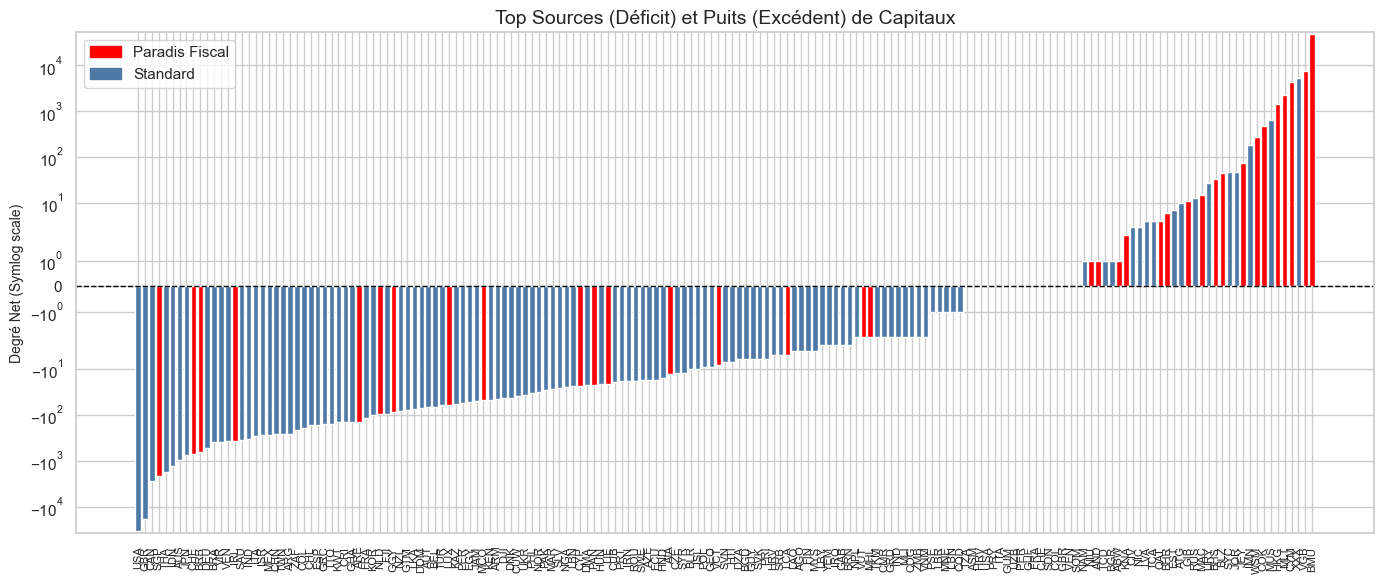

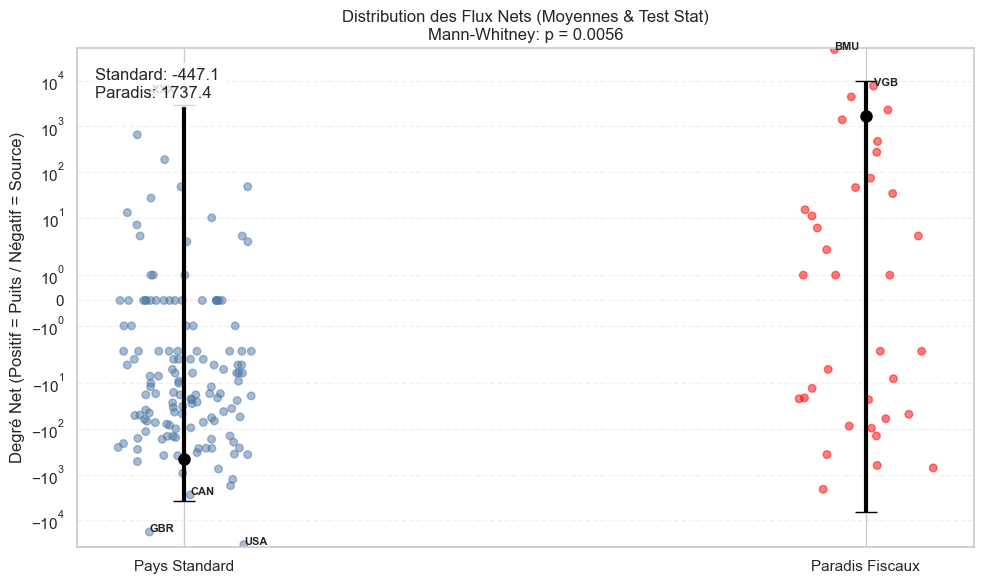

In [265]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.patches as mpatches

# --- 1. PRÉPARATION DES DONNÉES ---
data = [{'Country': n, 'Net_Degree': d.get('net_degree', 0), 'Is_Tax_Haven': d.get('is_tax_haven', 'No')} 
        for n, d in G_countries.nodes(data=True)]
df = pd.DataFrame(data).sort_values('Net_Degree')

# --- 2. GRAPHIQUE 1 : FLUX NETS (BAR CHART) ---
plt.figure(figsize=(14, 6))

df_plot = pd.concat([df.head(20), df.tail(20)]) if len(df) > 400 else df
colors = ['red' if x == "Yes" else '#4e79a7' for x in df_plot['Is_Tax_Haven']]

plt.bar(df_plot['Country'], df_plot['Net_Degree'], color=colors)
plt.axhline(0, color='black', lw=1, ls='--')
plt.yscale('symlog') # Gère le positif ET le négatif
plt.title("Top Sources (Déficit) et Puits (Excédent) de Capitaux", fontsize=14)
plt.ylabel("Degré Net (Symlog scale)", fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.legend(handles=[mpatches.Patch(color='red', label='Paradis Fiscal'), mpatches.Patch(color='#4e79a7', label='Standard')])
plt.tight_layout()
plt.show()

# --- 3. GRAPHIQUE 2 : COMPARAISON STATISTIQUE (STRIP PLOT) ---
# Préparation Jitter & Groupes
df['x_jitter'] = df['Is_Tax_Haven'].map({'No': 0, 'Yes': 1}) + np.random.uniform(-0.1, 0.1, len(df))
g_no = df[df['Is_Tax_Haven'] == 'No']['Net_Degree']
g_yes = df[df['Is_Tax_Haven'] == 'Yes']['Net_Degree']

# Stats Manuelles
mean_no, std_no = g_no.mean(), g_no.std()
mean_yes, std_yes = g_yes.mean(), g_yes.std()
stat, p_val = stats.mannwhitneyu(g_yes, g_no)
p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.4f}"

plt.figure(figsize=(10, 6))

# A. Points (Scatter)
colors_map = df['Is_Tax_Haven'].map({'Yes': 'red', 'No': '#4e79a7'})
plt.scatter(df['x_jitter'], df['Net_Degree'], c=colors_map, alpha=0.5, s=30)

# B. Moyennes + Écarts-types (Errorbar)
plt.errorbar(x=[0, 1], y=[mean_no, mean_yes], yerr=[std_no, std_yes], 
             fmt='o', color='black', linewidth=3, capsize=8, markersize=8, label='Moyenne ± Std')

# C. Labels des extrêmes (Top 3 et Bottom 3 pour éviter le désordre)
for idx, row in pd.concat([df.head(3), df.tail(3)]).iterrows():
    plt.text(row['x_jitter'], row['Net_Degree'], row['Country'], fontsize=8, fontweight='bold')

# D. Affichage
plt.xticks([0, 1], ['Pays Standard', 'Paradis Fiscaux'])
plt.yscale('symlog') # Indispensable pour voir les négatifs
plt.title(f"Distribution des Flux Nets (Moyennes & Test Stat)\nMann-Whitney: {p_text}", fontsize=12)
plt.ylabel("Degré Net (Positif = Puits / Négatif = Source)")
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Texte des statistiques
plt.text(0.02, 0.90, f"Standard: {mean_no:.1f}\nParadis: {mean_yes:.1f}", 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


nombre de pays dans le graphe des flux : 171


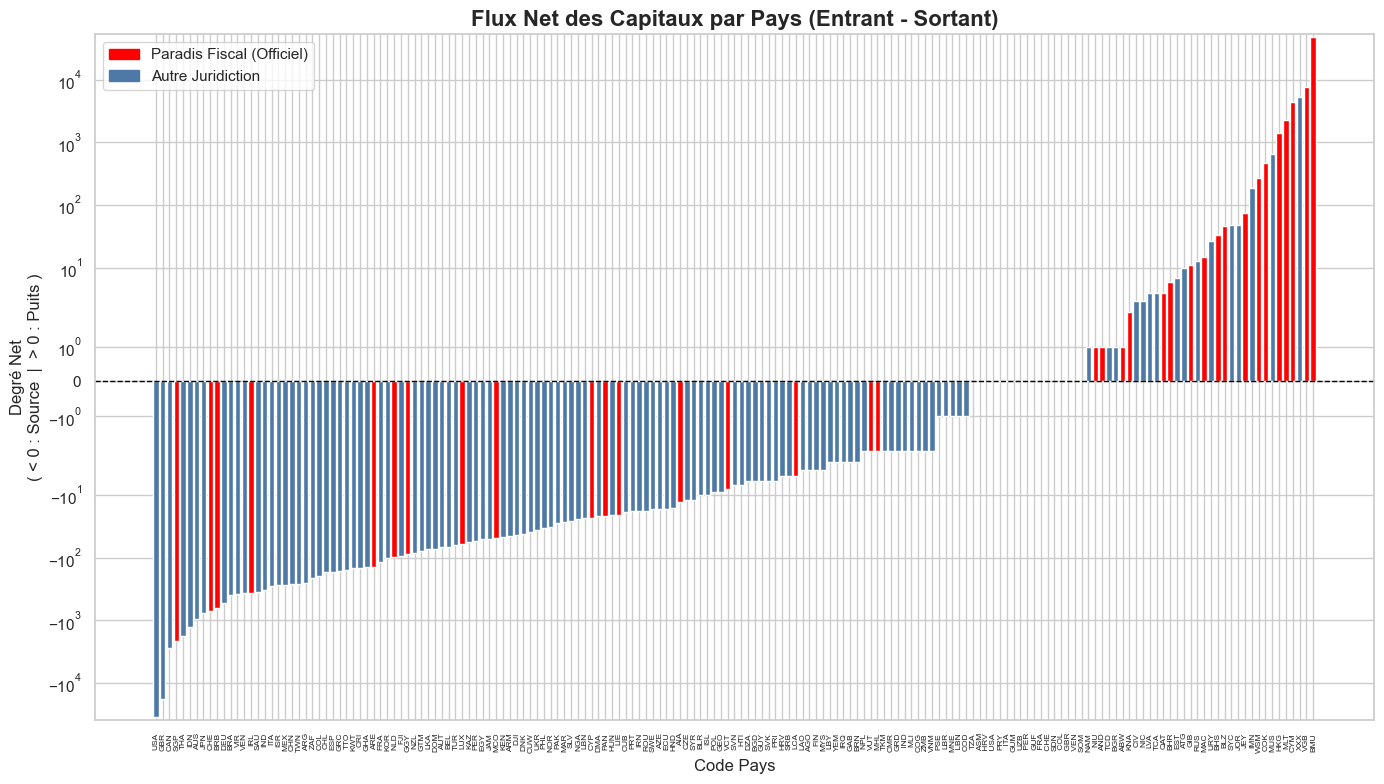

KeyError: 'net_degree'

In [266]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

print("nombre de pays dans le graphe des flux :", len(G_countries.nodes()))
# 1. Extraction des données du graphe vers un DataFrame
data_list = []
for country, attr in G_countries.nodes(data=True):
    data_list.append({
        'Country': country,
        'Net_Degree': attr.get('net_degree', 0),
        'Is_Tax_Haven': attr.get('is_tax_haven')  # Récupère "Yes" ou "No"
    })

df = pd.DataFrame(data_list)

# 2. Tri par Degré Net (du plus négatif au plus positif)
df = df.sort_values(by='Net_Degree', ascending=True)

# --- OPTIONNEL : DYNAMISER L'AFFICHAGE ---
# Si > 50 pays, on affiche seulement les extrêmes pour que ce soit lisible
# On prend les 20 plus gros déficits (Sources) et les 20 plus gros excédents (Puits)
if len(df) > 400:
    df_negative = df.head(20)
    df_positive = df.tail(20)
    df_plot = pd.concat([df_negative, df_positive])
else:
    df_plot = df

# 3. Configuration des couleurs
# Rouge si Paradis Fiscal ("Yes"), Bleu sinon ("No")
colors = ['red' if x == "Yes" else '#4e79a7' for x in df_plot['Is_Tax_Haven']]

# 4. Création du Graphique
plt.figure(figsize=(14, 8))

# On trace les barres
plt.bar(df_plot['Country'], df_plot['Net_Degree'], color=colors)

# Ligne zéro pour séparer sources et puits
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Mise en forme
plt.xticks(rotation=90, fontsize=6)
plt.title("Flux Net des Capitaux par Pays (Entrant - Sortant)", fontsize=16, fontweight='bold')
plt.ylabel("Degré Net\n( < 0 : Source  |  > 0 : Puits )", fontsize=12)
plt.yscale('symlog')  # Échelle symlog pour mieux visualiser les extrêmes
plt.xlabel("Code Pays", fontsize=12)

# Création de la légende manuellement
red_patch = mpatches.Patch(color='red', label='Paradis Fiscal (Officiel)')
blue_patch = mpatches.Patch(color='#4e79a7', label='Autre Juridiction')
plt.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

#Comparaison des degrés_net entre paradis fiscaux et autres pays

from scipy import stats

# 1. Préparation des données comme avant
category_map = {'No': 0, 'Yes': 1}
df['x_base'] = df['Is_Tax_Haven'].map(category_map)

# Jitter pour l'espacement
jitter_strength = 0.1
df['x_jittered'] = df['x_base'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
colors = df['Is_Tax_Haven'].map({'Yes': 'red', 'No': '#4e79a7'})

# ---------------------------------------------------------
# 2. CALCULS STATISTIQUES
# ---------------------------------------------------------
group_no = df[df['Is_Tax_Haven'] == 'No']['net_degree']
group_yes = df[df['Is_Tax_Haven'] == 'Yes']['net_degree']

# Moyennes et Écarts-types
mean_no, std_no = group_no.mean(), group_no.std()
mean_yes, std_yes = group_yes.mean(), group_yes.std()

# Test statistique (Mann-Whitney U est plus sûr pour les graphes que le T-test)
# H0 : Les distributions sont identiques
stat, p_value = stats.mannwhitneyu(group_yes, group_no, alternative='two-sided')

# Formatage du texte pour la p-value
if p_value < 0.001:
    p_text = "p < 0.001 (Très Significatif)"
else:
    p_text = f"p = {p_value:.4f}"

# ---------------------------------------------------------
# 3. VISUALISATION
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))

# A. Les points (Nuage de fond)
plt.scatter(df['x_jittered'], df['net_degree'], c=colors, alpha=0.5, s=40, edgecolors='none', label='Pays individuel')

# B. Les barres d'erreur (Moyenne + Écart-type)
# On les trace en noir par dessus pour bien les voir
plt.errorbar(
    x=[0, 1], 
    y=[mean_no, mean_yes], 
     
    fmt='o',        # 'o' pour marquer la moyenne par un point
    color='black', 
    ecolor='black', # Couleur de la barre
    elinewidth=3,   # Épaisseur de la barre
    capsize=10,     # Taille des "chapeaux"
    markersize=10, 
    label='Moyenne ± Écart-type'
)

# C. Étiquettes pour les pays importants (Top 10%)
threshold = df['net_degree'].quantile(0.10)
for i, row in df.iterrows():
    if row['net_degree'] > threshold:
        plt.text(
            row['x_jittered'], row['net_degree'], row['Country'], 
            fontsize=8, ha='left', va='bottom', fontweight='bold', alpha=0.8
        )

# D. Ajout des stats textuelles sur le graphe
stats_text = (
    f"Test Statistique (Mann-Whitney) : {p_text}\n\n"
    f"NON-Paradis : Moy = {mean_no:.4f} (± {std_no:.4f})\n"
    f"Paradis : Moy = {mean_yes:.4f} (± {std_yes:.4f})"
)

# On place le texte en haut à gauche (coordonnées relatives aux axes)
plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Mise en forme
plt.xticks([0, 1], ['Juridictions Standard', 'Paradis Fiscaux'], fontsize=12)
plt.ylabel("Betweenness Centrality", fontsize=12)
plt.yscale('log')  # Échelle logarithmique pour mieux visualiser
plt.title("Comparaison de la Betweenness", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



In [233]:
nx.write_gexf(G_countries, "country_flows_us_tax_havens.gexf")

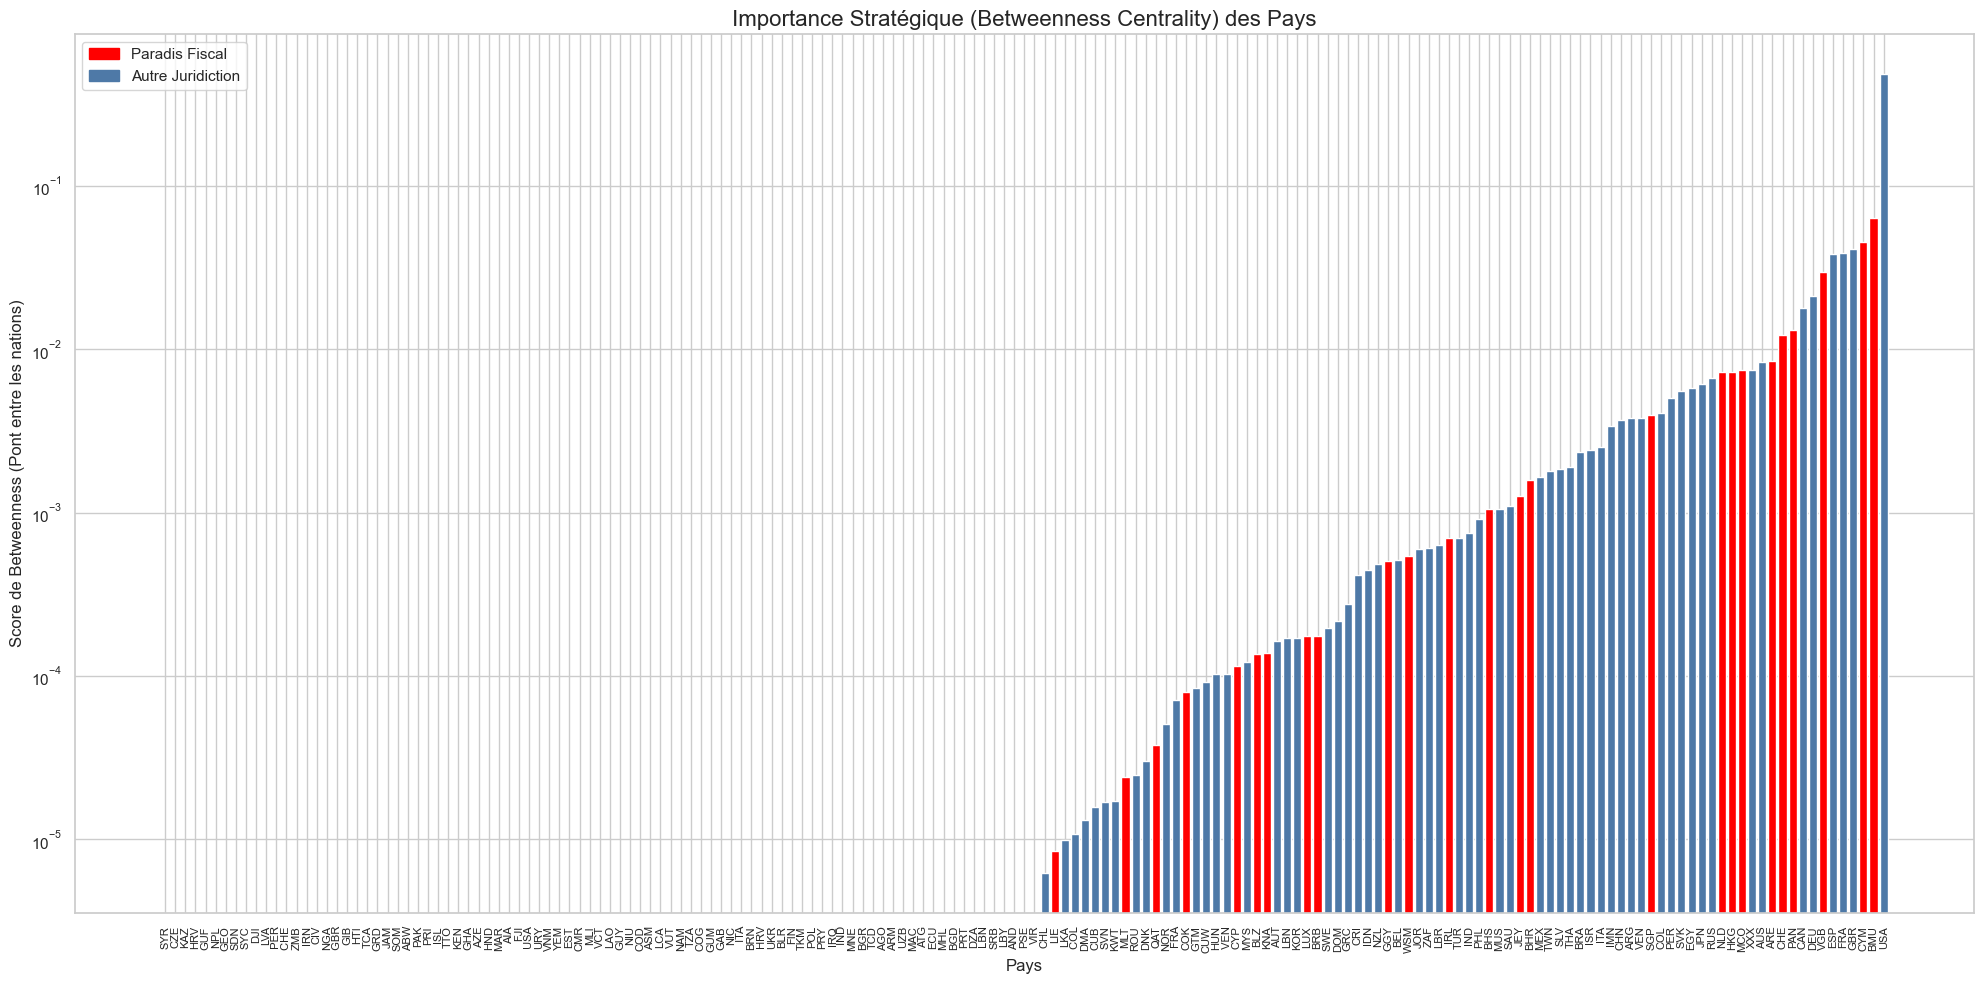

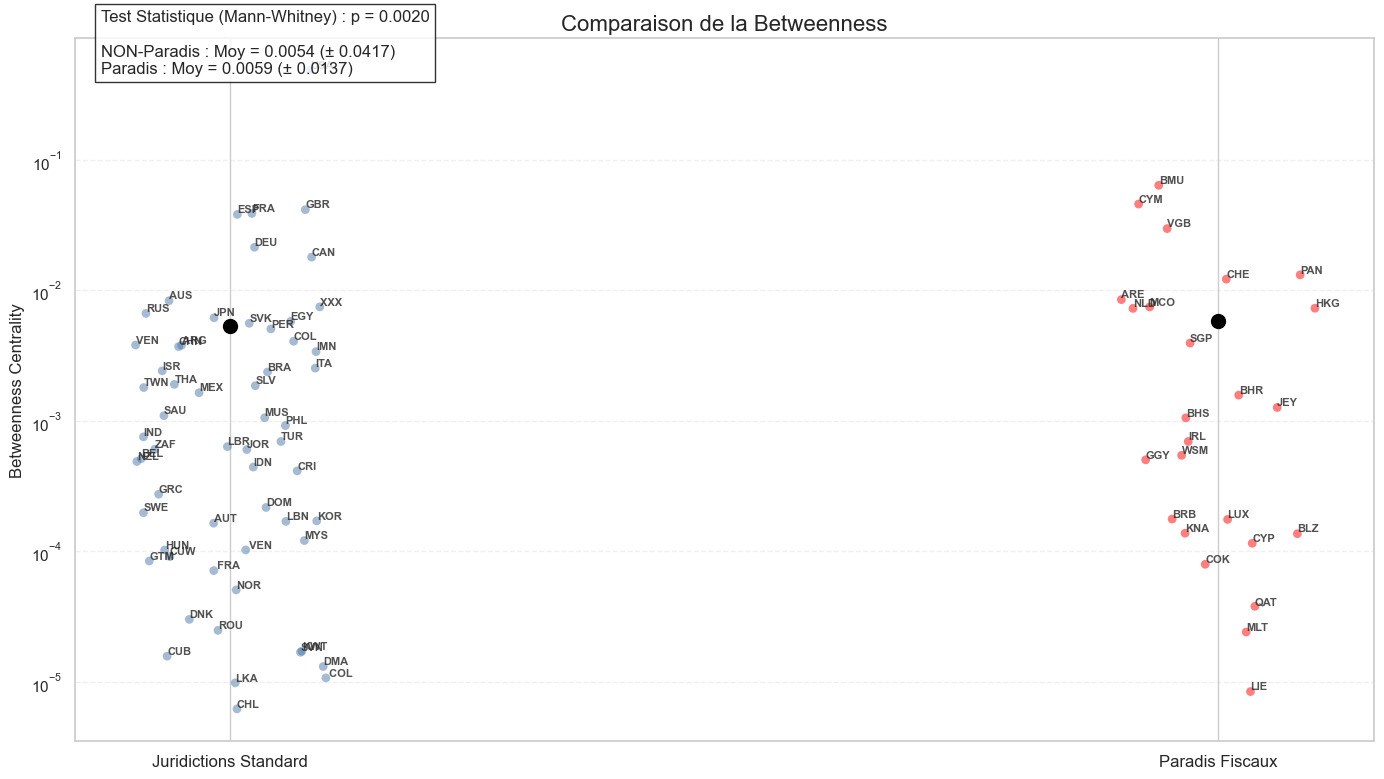

In [262]:
# 1. Extraction des données (Betweenness)
data_list = []
for country, attr in G_countries.nodes(data=True):
    data_list.append({
        'Country': country,
        'Betweenness': attr.get('betweenness', 0),
        'Is_Tax_Haven': attr.get('is_tax_haven', "No")
    })

df = pd.DataFrame(data_list)

# 2. Tri par Betweenness (Croissant)
# Les pays les plus "stratégiques" seront tout à droite
df = df.sort_values(by='Betweenness', ascending=True)

# 3. Configuration des couleurs
colors = ['red' if x == "Yes" else '#4e79a7' for x in df['Is_Tax_Haven']]

# 4. Création du Graphique
plt.figure(figsize=(20, 10)) # Format large pour tout afficher

plt.bar(df['Country'], df['Betweenness'], color=colors, width=0.8)

# Mise en forme
plt.xticks(rotation=90, fontsize=8) # Police petite pour voir tous les codes
plt.title("Importance Stratégique (Betweenness Centrality) des Pays", fontsize=16)
plt.ylabel("Score de Betweenness (Pont entre les nations)", fontsize=12)
plt.yscale('log')  # Échelle logarithmique pour mieux visualiser
plt.xlabel("Pays", fontsize=12)

# Légende
red_patch = mpatches.Patch(color='red', label='Paradis Fiscal')
blue_patch = mpatches.Patch(color='#4e79a7', label='Autre Juridiction')
plt.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()


#Comparaison des centralités entre paradis fiscaux et autres pays

from scipy import stats

# 1. Préparation des données comme avant
category_map = {'No': 0, 'Yes': 1}
df['x_base'] = df['Is_Tax_Haven'].map(category_map)

# Jitter pour l'espacement
jitter_strength = 0.1
df['x_jittered'] = df['x_base'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
colors = df['Is_Tax_Haven'].map({'Yes': 'red', 'No': '#4e79a7'})

# ---------------------------------------------------------
# 2. CALCULS STATISTIQUES
# ---------------------------------------------------------
group_no = df[df['Is_Tax_Haven'] == 'No']['Betweenness']
group_yes = df[df['Is_Tax_Haven'] == 'Yes']['Betweenness']

# Moyennes et Écarts-types
mean_no, std_no = group_no.mean(), group_no.std()
mean_yes, std_yes = group_yes.mean(), group_yes.std()

# Test statistique (Mann-Whitney U est plus sûr pour les graphes que le T-test)
# H0 : Les distributions sont identiques
stat, p_value = stats.mannwhitneyu(group_yes, group_no, alternative='two-sided')

# Formatage du texte pour la p-value
if p_value < 0.001:
    p_text = "p < 0.001 (Très Significatif)"
else:
    p_text = f"p = {p_value:.4f}"

# ---------------------------------------------------------
# 3. VISUALISATION
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))

# A. Les points (Nuage de fond)
plt.scatter(df['x_jittered'], df['Betweenness'], c=colors, alpha=0.5, s=40, edgecolors='none', label='Pays individuel')

# B. Les barres d'erreur (Moyenne + Écart-type)
# On les trace en noir par dessus pour bien les voir
plt.errorbar(
    x=[0, 1], 
    y=[mean_no, mean_yes], 
     
    fmt='o',        # 'o' pour marquer la moyenne par un point
    color='black', 
    ecolor='black', # Couleur de la barre
    elinewidth=3,   # Épaisseur de la barre
    capsize=10,     # Taille des "chapeaux"
    markersize=10, 
    label='Moyenne ± Écart-type'
)

# C. Étiquettes pour les pays importants (Top 10%)
threshold = df['Betweenness'].quantile(0.10)
for i, row in df.iterrows():
    if row['Betweenness'] > threshold:
        plt.text(
            row['x_jittered'], row['Betweenness'], row['Country'], 
            fontsize=8, ha='left', va='bottom', fontweight='bold', alpha=0.8
        )

# D. Ajout des stats textuelles sur le graphe
stats_text = (
    f"Test Statistique (Mann-Whitney) : {p_text}\n\n"
    f"NON-Paradis : Moy = {mean_no:.4f} (± {std_no:.4f})\n"
    f"Paradis : Moy = {mean_yes:.4f} (± {std_yes:.4f})"
)

# On place le texte en haut à gauche (coordonnées relatives aux axes)
plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Mise en forme
plt.xticks([0, 1], ['Juridictions Standard', 'Paradis Fiscaux'], fontsize=12)
plt.ylabel("Betweenness Centrality", fontsize=12)
plt.yscale('log')  # Échelle logarithmique pour mieux visualiser
plt.title("Comparaison de la Betweenness", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [288]:
#Print des noms des 20 noeuds avec la plus haute betweenness
top_20_betweenness = sorted(G_countries.nodes(data=True), key=lambda x: x[1].get('betweenness', 0), reverse=True)[:20]
print("Top 20 des pays par Betweenness Centrality :")
for country, attr in top_20_betweenness:
    print(f"{country}: {attr.get('betweenness', 0):.6f}")

Top 20 des pays par Betweenness Centrality :
USA: 0.482993
BMU: 0.063728
CYM: 0.045764
GBR: 0.041420
FRA: 0.038779
ESP: 0.038118
VGB: 0.029676
DEU: 0.021364
CAN: 0.017951
PAN: 0.013125
CHE: 0.012170
ARE: 0.008484
AUS: 0.008320
XXX: 0.007465
MCO: 0.007456
HKG: 0.007290
NLD: 0.007267
RUS: 0.006657
JPN: 0.006163
EGY: 0.005779
